In [1]:
import numpy as np
from datetime import datetime, timedelta, date
import os
import netCDF4
import h5py
# Extract date from filename
import os
import re
# from tqdm import tqdm
import pickle
from numpy.lib.stride_tricks import as_strided
import xarray as xr

# ==================== Configuration ====================
results_path = '/glade/work/bgong'
data_root_path = '/glade/campaign/univ/uchi0014/yqsun/pangu_s2s/'


'''
3 seeds version:
FC: 
/glade/campaign/univ/uchi0014/weidong/FB/results/ERA5/S2S_8001/    ~ 45 seed1
FC_len, BC_len = 45, 20

/glade/derecho/scratch/yqsun/FB/s2s-retrainD/results/S2S/1003/predictions/   seed2
/glade/campaign/univ/uchi0014/yqsun/s2s-retrainD/results/S2S/1002/predictions/   seed3   ~~ replace


BC: 
/glade/derecho/scratch/yqsun/FB/s2s-retrainE-BC/results/S2S/2003/predictions/   seed1
/glade/derecho/scratch/yqsun/FB/s2s-retrainE-BC/results/S2S/2004/predictions/   seed2
/glade/derecho/scratch/yqsun/FB/s2s-retrainE-BC/results/S2S/2005/predictions/   seed3   ~~ replace
'''

FC_len, BC_len = 45, 20
model_name = 'FC-BC_seed1'
print(model_name)
is_FC_s2s = True
FC_idx, BC_idx = '8001', '2003'

# ==================== Regional Configuration ====================
# Options: 'global', 'tropics', 'NH', 'SH'
# tropics: 30S-30N
# NH: 30N-90N
# SH: 90S-30S
REGION = 'global'  # Change this to 'global', 'tropics', 'NH', or 'SH'

REGION_CONFIG = {
    'global': {'lat_min': -90, 'lat_max': 90, 'suffix': ''},
    'tropics': {'lat_min': -30, 'lat_max': 30, 'suffix': '_tropics'},
    'NH': {'lat_min': 30, 'lat_max': 90, 'suffix': '_NH'},
    'SH': {'lat_min': -90, 'lat_max': -30, 'suffix': '_SH'},
}

upper_air_vars = ['u_component_of_wind', 'v_component_of_wind',
                  'temperature', 'specific_humidity', 'geopotential']
surface_vars = ['2m_temperature','10m_u_component_of_wind','10m_v_component_of_wind',
                'mean_sea_level_pressure','surface_pressure',
                'sea_surface_temperature',
                'skin_temperature','soil_temperature_level_1','volumetric_soil_water_layer_1']

levs = [5, 10, 20, 30, 50, 70, 100, 150, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
if is_FC_s2s:
    plevs_fc = [5, 10, 20, 30, 50, 70, 100, 150, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
    plevs_bc = [5, 10, 20, 30, 50, 70, 100, 150, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
else:
    plevs_fc = [5, 10, 20, 30, 50, 70, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
    plevs_bc = [5, 10, 20, 30, 50, 70, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]

# ==================== Utility Functions ====================
def gen_weights(lat):
    """Generate cosine latitude weights"""
    lon = np.arange(0, 360, 1)
    weights = np.cos(lat*np.pi/180)
    W = np.tile(weights, (len(lon), 1)).T
    return W

def gen_regional_mask(lat, lat_min, lat_max):
    """Generate regional mask based on latitude bounds"""
    lon = np.arange(0, 360, 1)
    mask = (lat >= lat_min) & (lat <= lat_max)
    M = np.tile(mask, (len(lon), 1)).T
    return M

# Full latitude array (assuming 1-degree resolution from 89.5 to -89.5)
lat_array = np.arange(89.5, -89.5-0.5, -1)
weight = gen_weights(lat_array)

# Generate regional mask
region_config = REGION_CONFIG[REGION]
regional_mask = gen_regional_mask(lat_array, region_config['lat_min'], region_config['lat_max'])
print(f"Region: {REGION} (lat: {region_config['lat_min']} to {region_config['lat_max']})")

def weighted_average(X, W, mask=None):
    """Compute weighted average, optionally with regional mask"""
    if W.shape != X.shape:
        W = np.broadcast_to(W, X.shape)
    if mask is not None:
        if mask.shape != X.shape:
            mask = np.broadcast_to(mask, X.shape)
        indices = ~np.isnan(X) & mask
    else:
        indices = ~np.isnan(X)
    z = np.average(X[indices], weights=W[indices])
    return z

def metric_rmse(F, A, W, mask=None):
    X = np.square(F - A)
    return np.sqrt(weighted_average(X, W, mask))

def metric_acc(F, A, W, mask=None):
    F = np.squeeze(F)
    A = np.squeeze(A)
    a = weighted_average(F*A, W, mask)
    b = np.sqrt(weighted_average(A*A, W, mask))
    c = np.sqrt(weighted_average(F*F, W, mask))
    return a/b/c

def to_file_format(dt: datetime) -> str:
    year = dt.year
    year_start = datetime(year, 1, 1, 0, 0, 0)
    delta = dt - year_start
    step = delta.days * 4 + delta.seconds // 21600
    return f"{year}_{step:04d}"

def current_date_to_file_format(initial_date, lead_time):
    start_date = datetime.strptime(initial_date, "%Y-%m-%d")
    new_date = start_date + timedelta(days=lead_time)
    date_str = to_file_format(new_date)
    return date_str

# ==================== Data Loading Functions ====================
def load_GT(date_str, var_name, level):
    h5file = h5py.File(f"{data_root_path}/h5data/{date_str}.h5", "r")
    if var_name in upper_air_vars:
        lev_str = f"{level:.1f}"
        var_full_name = f"input/{var_name}_{lev_str}"
    else:
        var_full_name = f"input/{var_name}"
    data = h5file[var_full_name][:].data[::-1]
    h5file.close()
    return data



FC-BC_seed1
Region: global (lat: -90 to 90)


In [2]:
    # Get regional configuration
region_cfg = REGION_CONFIG[REGION]
regional_mask = gen_regional_mask(lat_array, region_cfg['lat_min'], region_cfg['lat_max'])
region_suffix = region_cfg['suffix']

print(f"\n{'='*60}")
print(f"Computing metrics for region: {REGION}")
print(f"Latitude range: {region_cfg['lat_min']} to {region_cfg['lat_max']}")
print(f"{'='*60}")


Computing metrics for region: global
Latitude range: -90 to 90


In [3]:
# Load climatology
climatology = netCDF4.Dataset(f'{data_root_path}1979-2018_mean_climatology.nc')
climatology.variables.keys()
var_name = "2m_temperature" #geopotential
if var_name in upper_air_vars:
    var_clim_all = climatology[var_name][:, levs.index(level), ::-1]
else:
    var_clim_all = climatology[var_name][:, ::-1]

def load_clim(date_str):
    var_clim = var_clim_all[int(int(date_str[5:])/4)]
    return var_clim

In [36]:
dirs = "/glade/campaign/univ/uchi0018/bing/determinstic_prediction/roll_out_step2_prediction_weights"


In [37]:
#file="/glade/campaign/univ/uchi0018/bing/determinstic_prediction/roll_out_step2_prediction/pangu_plasim_11_24h_10step_2020052300_ens_0.nc"
def get_date(file):
    filename = os.path.basename(file)
    # Pattern to match date format YYYYMMDDHH in the filename
    date_match = re.search(r'(\d{10})', filename)
    if date_match:
        date_from_file = date_match.group(1)
        print(f"Date from filename: {date_from_file}")
        # Format as YYYY-MM-DD HH
        year = date_from_file[:4]
        month = date_from_file[4:6]
        day = date_from_file[6:8]
        hour = date_from_file[8:10]
        formatted_date = f"{year}-{month}-{day}"
        print(f"Formatted date: {formatted_date}")
        return formatted_date
    else:
        print("No date found in filename")
        return None

In [38]:
 # Get all files from the directory and extract dates
import glob
files = glob.glob(os.path.join(dirs, "*.nc"))
print(f"Found {len(files)} files")

# # Extract dates from all files
acc_fc_list_files, rmse_fc_list_files = [], []
for file in files:
    selected_date = get_date(file)
    fc = xr.open_dataset(file)[var_name]
    acc_fc_list, rmse_fc_list = [], []
    try: 
        for i in range(45):
            # print("lead time ",i)
            date_str = current_date_to_file_format(selected_date, lead_time=i)
            var_GT_data = load_GT(date_str, var_name, 0)
            var_clim_data = load_clim(date_str)
            var_GT_anom = var_GT_data - var_clim_data
            FC_var = fc.isel(time=i).values[::-1, :]
            fc_anom =  FC_var - var_clim_data
            rmse_fc_list.append(metric_rmse(FC_var, var_GT_data, weight, regional_mask))
            acc_fc_list.append(metric_acc(fc_anom, var_GT_anom, weight, regional_mask))
        acc_fc_list_files.append(acc_fc_list)
        rmse_fc_list_files.append(rmse_fc_list)
    except:
        print("error") 
        


Found 99 files
Date from filename: 2020070100
Formatted date: 2020-07-01
Date from filename: 2019052700
Formatted date: 2019-05-27
Date from filename: 2020070400
Formatted date: 2020-07-04
Date from filename: 2021062400
Formatted date: 2021-06-24
Date from filename: 2020061000
Formatted date: 2020-06-10
Date from filename: 2019051600
Formatted date: 2019-05-16
Date from filename: 2019062700
Formatted date: 2019-06-27
Date from filename: 2019072200
Formatted date: 2019-07-22
Date from filename: 2020072200
Formatted date: 2020-07-22
Date from filename: 2022062000
Formatted date: 2022-06-20
Date from filename: 2021072500
Formatted date: 2021-07-25
Date from filename: 2020062400
Formatted date: 2020-06-24
Date from filename: 2019072900
Formatted date: 2019-07-29
Date from filename: 2021062000
Formatted date: 2021-06-20
Date from filename: 2019061000
Formatted date: 2019-06-10
Date from filename: 2021060600
Formatted date: 2021-06-06
Date from filename: 2021051300
Formatted date: 2021-05-13

In [39]:
acc_fc_list_files_roll_out2 = np.array(acc_fc_list_files)

In [42]:
acc_fc_list_files_roll_out2

array([[1.        , 0.96701806, 0.94530673, ..., 0.34966159, 0.35660998,
        0.34141225],
       [1.        , 0.96493092, 0.94217164, ..., 0.28589712, 0.31207422,
        0.32717263],
       [1.        , 0.96287275, 0.9423603 , ..., 0.25303924, 0.28620154,
        0.28359264],
       ...,
       [1.        , 0.96842524, 0.95085919, ..., 0.14472295, 0.13863265,
        0.16330294],
       [1.        , 0.9657548 , 0.94182859, ..., 0.2212615 , 0.18045932,
        0.1932947 ],
       [1.        , 0.97216905, 0.95593453, ..., 0.39809107, 0.33803261,
        0.32989491]], shape=(98, 45))

In [49]:
np.mean(acc_fc_list_files_roll_out2, axis=0)

array([1.        , 0.96399881, 0.94174924, 0.91413523, 0.87776005,
       0.8315921 , 0.77512215, 0.70991317, 0.64679594, 0.58664706,
       0.53473455, 0.49023064, 0.45958879, 0.43546126, 0.40644586,
       0.39105391, 0.37840658, 0.36028223, 0.34931998, 0.34745791,
       0.33824   , 0.3279288 , 0.32285366, 0.31366587, 0.30586822,
       0.30593442, 0.30337192, 0.29887667, 0.29882011, 0.29977735,
       0.29789274, 0.28808339, 0.28471074, 0.28605041, 0.28666138,
       0.28595814, 0.28939142, 0.2781762 , 0.26905488, 0.26207951,
       0.25772755, 0.25678099, 0.25799241, 0.26702469, 0.27344016])

In [ ]:
# np.mean(acc_fc_list_files_roll_out2, axis=0)

array([1.        , 0.97321792, 0.95836528, 0.93747924, 0.90749796,
       0.86476391, 0.80950002, 0.74275279, 0.67968772, 0.61307285,
       0.55572197, 0.50237149, 0.46619419, 0.43476251, 0.41356945,
       0.39608653, 0.38295879, 0.37326003, 0.36335845, 0.34776712,
       0.33897691, 0.33851433, 0.33934353, 0.33067852, 0.32643229,
       0.33001094, 0.32474724, 0.31533678, 0.3147112 , 0.31678055,
       0.31109161, 0.29951002, 0.30696351, 0.30525184, 0.29937946,
       0.28510097, 0.28470369, 0.28751867, 0.28958601, 0.29155796,
       0.28849477, 0.2968991 , 0.29405225, 0.28444105, 0.2867383 ])

In [ ]:
# with open('acc_fc_list_roll_out2.pkl', 'wb') as f:
#     pickle.dump(acc_fc_list_files_roll_out2, f)

# print("Saved acc_fc_list_files_roll_out2 to acc_fc_list_roll_out2.pkl")

Saved acc_fc_list_files_roll_out2 to acc_fc_list_roll_out2.pkl


In [50]:
# Calculate mean along first dimension (across all files)
acc_mean_roll_out2 = np.mean(acc_fc_list_files_roll_out2, axis=0)
print(f"ACC mean for each lead time: {acc_mean_roll_out2 }")

ACC mean for each lead time: [1.         0.96399881 0.94174924 0.91413523 0.87776005 0.8315921
 0.77512215 0.70991317 0.64679594 0.58664706 0.53473455 0.49023064
 0.45958879 0.43546126 0.40644586 0.39105391 0.37840658 0.36028223
 0.34931998 0.34745791 0.33824    0.3279288  0.32285366 0.31366587
 0.30586822 0.30593442 0.30337192 0.29887667 0.29882011 0.29977735
 0.29789274 0.28808339 0.28471074 0.28605041 0.28666138 0.28595814
 0.28939142 0.2781762  0.26905488 0.26207951 0.25772755 0.25678099
 0.25799241 0.26702469 0.27344016]


In [28]:
import pickle

# Load ACC data
with open('acc_fc_list_roll_out2.pkl', 'rb') as f:
    acc_fc_list_files_ro1 = pickle.load(f)

print("Loaded acc_fc_list_files_roll_out2")
print(f"Shape: {acc_fc_list_files_roll_out2.shape}")

# Load RMSE data
with open('/glade/work/bgong/benchmark-dev/metrics/acc_fc_list_epoch_100.pkl', 'rb') as f:
    acc_fc_list_epoch100 = pickle.load(f)



Loaded acc_fc_list_files_roll_out2
Shape: (24, 45)


In [47]:
acc_mean_roll_out2 = np.mean(acc_fc_list_files_roll_out2, axis=0)
acc_mean_epoch100 = np.mean(acc_fc_list_epoch100, axis=0)

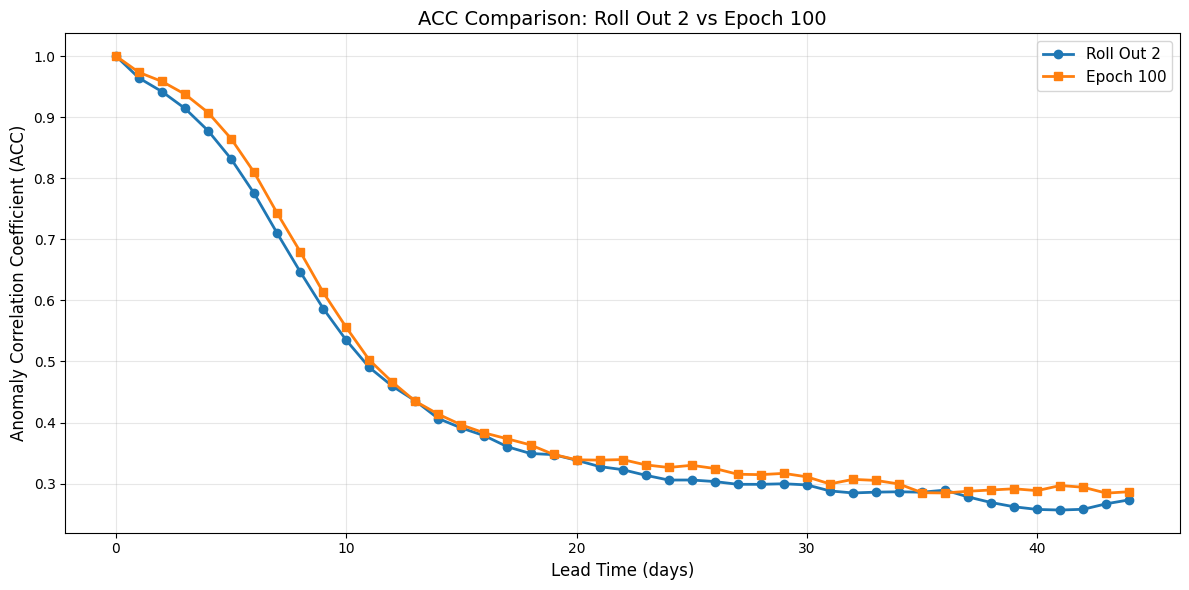

Roll Out 2 - Mean ACC: 0.4368
Epoch 100 - Mean ACC: 0.4535
Difference (Roll Out 2 - Epoch 100): -0.0167


In [48]:
# Create lead time array (assuming daily forecasts for 45 days)
import matplotlib.pyplot as plt

lead_times = np.arange(len(acc_mean_roll_out2))

# Create comparison plot
plt.figure(figsize=(12, 6))
plt.plot(lead_times, acc_mean_roll_out2, marker='o', label='Roll Out 2', linewidth=2)
plt.plot(lead_times, acc_mean_epoch100, marker='s', label='Epoch 100', linewidth=2)
plt.xlabel('Lead Time (days)', fontsize=12)
plt.ylabel('Anomaly Correlation Coefficient (ACC)', fontsize=12)
plt.title('ACC Comparison: Roll Out 2 vs Epoch 100', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('acc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"Roll Out 2 - Mean ACC: {np.mean(acc_mean_roll_out2):.4f}")
print(f"Epoch 100 - Mean ACC: {np.mean(acc_mean_epoch100):.4f}")
print(f"Difference (Roll Out 2 - Epoch 100): {np.mean(acc_mean_roll_out2) - np.mean(acc_mean_epoch100):.4f}")

In [23]:
rmse_mean_roll_out2 = np.mean(rmse_fc_list_files, axis=0)

In [24]:
rmse_mean_roll_out2 

array([0.        , 0.79774018, 1.03861686, 1.27754279, 1.54014225,
       1.81916787, 2.12030629, 2.39411221, 2.62377827, 2.84328316,
       3.01611059, 3.17770455, 3.28532397, 3.42311686, 3.53022015,
       3.5993379 , 3.69594924, 3.77142468, 3.77275418, 3.80999873,
       3.92060659, 3.9695325 , 3.92217642, 3.96425703, 4.02391686,
       4.04636604, 4.13537474, 4.21397278, 4.21462295, 4.23053205,
       4.24619688, 4.28653985, 4.31718933, 4.36545735, 4.43638355,
       4.47997441, 4.51098671, 4.52985689, 4.59103847, 4.61686812,
       4.64877209, 4.69512272, 4.71134259, 4.72714812, 4.76188959])

In [65]:
with open('rmse_mean_epoch_100.pkl', 'wb') as f:
    pickle.dump(rmse_mean_roll_out2, f)

print("Saved rmse_mean_roll_out2 to rmse_mean_roll_out2.pkl")

Saved rmse_mean_roll_out2 to rmse_mean_roll_out2.pkl


In [31]:
with open('rmse_mean_roll_out2.pkl', 'rb') as f:
    rmse_mean_roll_out2 = pickle.load(f)


# Load RMSE data
with open('/glade/work/bgong/benchmark-dev/metrics/rmse_mean_epoch_100.pkl', 'rb') as f:
    rmse_mean_epoch100 = pickle.load(f)

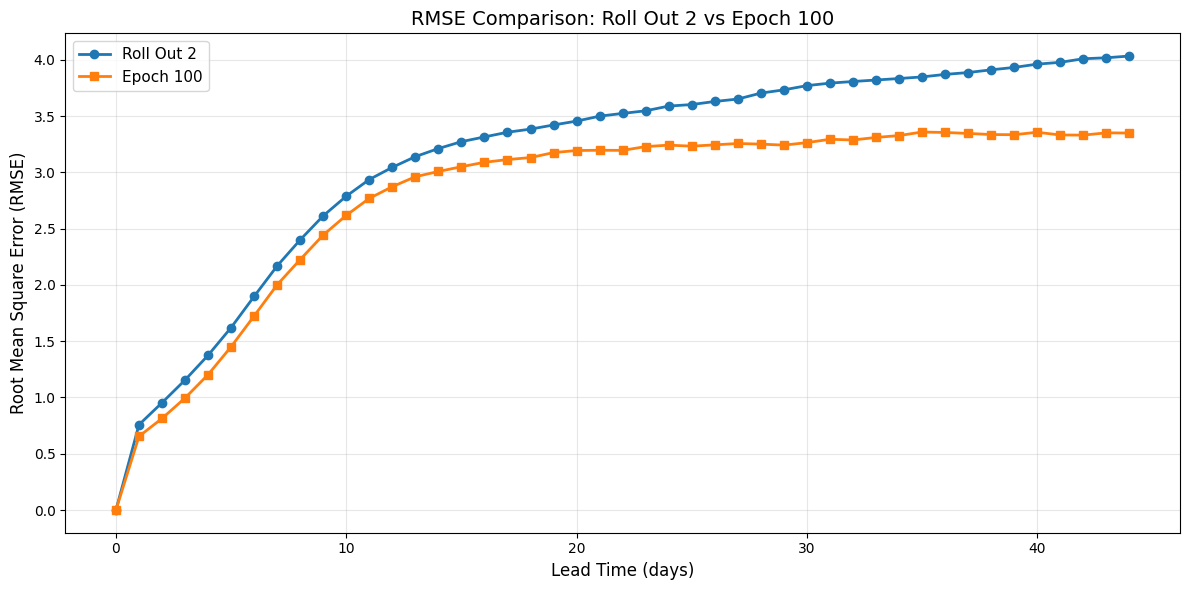

Roll Out 2 - Mean RMSE: 3.1389
Epoch 100 - Mean RMSE: 2.7898
Difference (Roll Out 2 - Epoch 100): 0.3491


In [32]:
# Create lead time array
import matplotlib.pyplot as plt
lead_times = np.arange(len(rmse_mean_roll_out2))

# Create RMSE comparison plot
plt.figure(figsize=(12, 6))
plt.plot(lead_times, rmse_mean_roll_out2, marker='o', label='Roll Out 2', linewidth=2)
plt.plot(lead_times, rmse_mean_epoch100, marker='s', label='Epoch 100', linewidth=2)
plt.xlabel('Lead Time (days)', fontsize=12)
plt.ylabel('Root Mean Square Error (RMSE)', fontsize=12)
plt.title('RMSE Comparison: Roll Out 2 vs Epoch 100', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rmse_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"Roll Out 2 - Mean RMSE: {np.mean(rmse_mean_roll_out2):.4f}")
print(f"Epoch 100 - Mean RMSE: {np.mean(rmse_mean_epoch100):.4f}")
print(f"Difference (Roll Out 2 - Epoch 100): {np.mean(rmse_mean_roll_out2) - np.mean(rmse_mean_epoch100):.4f}")

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

In [6]:
dt = xr.open_dataset("/glade/work/bgong/pangu_plasim_14_24h_1step_2018010100_ens_0.nc")

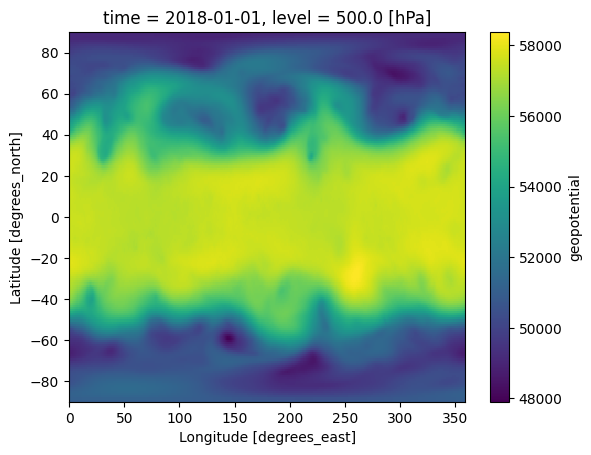

In [11]:
dt["geopotential"].sel(level=500).isel(time=0).plot()

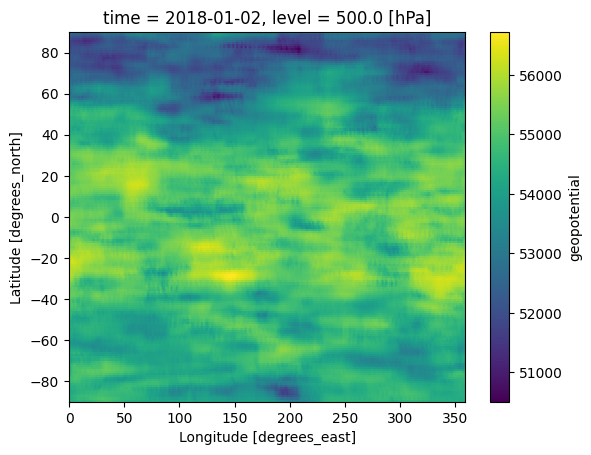

In [12]:
dt["geopotential"].sel(level=500).isel(time=1).plot()